In [12]:
import cantera as ct
ct.__version__

'2.6.0'

In [1]:
import yaml
import sys
import os
import glob
from copy import deepcopy
repo_dir = os.path.dirname(os.path.dirname(os.path.abspath("")))
sys.path.append(repo_dir)
from rmg_gua.gua_peuqse.runtime_utilities import get_all_param_lists

In [7]:
from rmg_gua.gua_peuqse.peuqse_utilities import trim_expts
import pandas as pd 

settings_path = os.path.join(repo_dir, "rmg_gua", "gua_cantera", "experiments_reorg_onlyopt.yaml")
# open the yaml file and get the list of experiments
with open(settings_path, "r") as f:
    expt_list = yaml.load(f, Loader=yaml.FullLoader)

expt_data = expt_list
flat_expt_data = []
for i, expt in enumerate(expt_data):
    flat_output = {}
    for key, value in expt.items(): 
        if key == "species":
                for keysub, valuesub in expt[key].items():
                    flat_output[key+" "+keysub] = valuesub
        else: 
            flat_output[key] = value
    flat_expt_data.append(flat_output)

flat_expt_df = pd.DataFrame(flat_expt_data)


In [8]:
import itertools
import numpy as np

# drop any 
# make new column for h2 to co+co2 ratio and co to co2
flat_expt_df["h2/(co+co2)"] = flat_expt_df["species H2"]/(flat_expt_df["species CO"] + flat_expt_df["species CO2"])
flat_expt_df["co/co2"] = flat_expt_df["species CO"]/flat_expt_df["species CO2"]

# get min/max values for each parameter
pminmax = flat_expt_df["pressure"].min(), flat_expt_df["pressure"].max()
tminmax = flat_expt_df["temperature"].min(), flat_expt_df["temperature"].max()
ratioh2minmax = flat_expt_df["h2/(co+co2)"].min(), flat_expt_df["h2/(co+co2)"].max()
ratiocominmax = flat_expt_df["co/co2"].min(), flat_expt_df["co/co2"].max()

# get set of experiments that have combinations of low and high for each parameter
expt_combos = {"p": pminmax, "t": tminmax, "ratioh2": ratioh2minmax, "ratioco": ratiocominmax}
expt_combos = list(itertools.product(*expt_combos.values()))

# Remove criteria for h2 ratio, makes it too restrictive, and without it we
# end up having a variety of h2 rations anyway
rtol = 1.0
peuqse_expts = pd.DataFrame()
for expset in expt_combos: 
    next_series = flat_expt_df[np.isclose(flat_expt_df["pressure"], expset[0], rtol=0.5) & \
        (np.isclose(flat_expt_df["temperature"], expset[1], atol=20)) & \
        (np.isclose(flat_expt_df["co/co2"], expset[3], rtol=0.5))]
    if next_series.empty:
        print("No experiments found for", expset)
        
    else: 
        # remove indices that are already in the dataframe
        next_series = next_series[~next_series.index.isin(peuqse_expts.index)]
        peuqse_expts = pd.concat([peuqse_expts,next_series.head(1)])

# they didn't do experiments with [low h2 low co/co2] or [high h2 high co/co2] 
# convert dataframe to dictionary
# remove the h2/co+co2 and co/co2 columns we made
peuqse_expts = peuqse_expts.drop(columns=["h2/(co+co2)", "co/co2"])
peuqse_expts_dict = peuqse_expts.to_dict(orient="records")

# now unflatten the species sub-dictionary
new_peuqse_expts_dict = []
for i, expt in enumerate(peuqse_expts_dict):
    flat_output = {}
    for key, value in expt.items(): 
        if key.startswith("species "):
            keysub = key.split(" ")[1]
            if "species" not in flat_output.keys():
                flat_output["species"] = {}
            flat_output["species"][keysub] = value
        else: 
            flat_output[key] = value
    new_peuqse_expts_dict.append(flat_output)

No experiments found for (1470000.0, 516.7, 1.6666666666666667, 0.0)
No experiments found for (1470000.0, 516.7, 9.0, 0.0)
No experiments found for (5030000.0, 516.7, 1.6666666666666667, 0.0)
No experiments found for (5030000.0, 516.7, 9.0, 0.0)


In [10]:
new_peuqse_expts_dict

[{'catalyst_area': 44.424193000339805,
  'experiment_type': 'sbr',
  'expt_name': 'graaf_1988',
  'output': {'CH3OH': 0.0007481650561503432, 'H2O': 0.001043658817823168},
  'pressure': 1510000.0,
  'run_num': 145.0,
  'species': {'CO': 0.0, 'CO2': 0.115, 'H2': 0.885},
  'species_out': {'CH3OH': 0.0119,
   'CO': 0.0043,
   'CO2': 0.101,
   'H2': 0.8661,
   'H2O': 0.0166},
  'temperature': 483.5,
  'use_for_opt': True,
  'volume': 0.0001346957850226624,
  'volume_flowrate': 2.01e-06},
 {'catalyst_area': 44.424193000339805,
  'experiment_type': 'sbr',
  'expt_name': 'graaf_1988',
  'output': {'CH3OH': 0.00113111521219569, 'H2O': 0.00016158788745652717},
  'pressure': 1540000.0,
  'run_num': 88.0,
  'species': {'CO': 0.12, 'CO2': 0.021, 'H2': 0.859},
  'species_out': {'CH3OH': 0.0063,
   'CO': 0.117,
   'CO2': 0.02,
   'H2': 0.8558,
   'H2O': 0.0009},
  'temperature': 483.5,
  'use_for_opt': True,
  'volume': 0.0001346957850226624,
  'volume_flowrate': 5.74e-06},
 {'catalyst_area': 44.4241

In [13]:
mech_path = "/scratch/blais.ch/methanol_unc_data/peuqse_runs/peuqse_methanol_runs/rmg_model/cantera/chem_annotated.yaml"
gas = ct.Solution(mech_path, "gas")
surf = ct.Interface(mech_path, "surface1", [gas])
gas.TPX = 500, 1e5, {'CO2(4)':0.0, 'CO(3)': 0.05, 'H2(2)': 0.9}

In [5]:
folders = glob.glob(os.path.join(repo_dir, "rmg_gua", "gua_peuqse", "peuqse_runs/*"))
proj_path = os.path.join(folders[3], "peuqse","pickles")
proj_path

'/work/westgroup/ChrisB/_01_MeOH_repos/uncertainty_analysis/rmg_gua/gua_peuqse/peuqse_runs/04_logp_opt_linear_checkpoint/peuqse/pickles'

In [6]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [7]:
maplogp_path = os.path.join(proj_path, "mcmc_map_logP.pkl")
with open(maplogp_path, "rb") as f: 
    maplogp = pickle.load(f)
maplogp

array([-18.59115889])

In [8]:
pickle_path = os.path.join(proj_path, "mcmc_logP_and_parameter_samples.pkl")
with open(pickle_path, "rb") as f: 
    psample = pickle.load(f)

In [9]:
60000/(22*60)

45.45454545454545

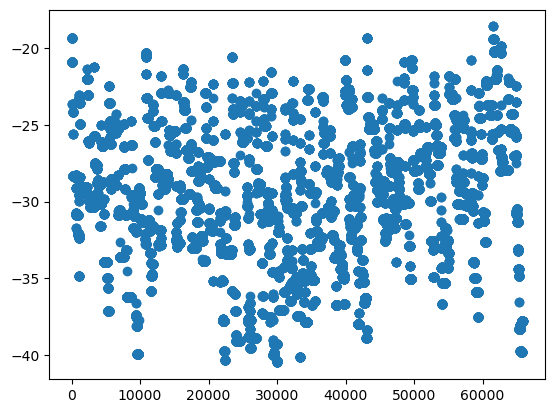

In [7]:
logps = [sample[0] for sample in psample]
x = np.arange(0,len(logps), 1)
plt.scatter(x, logps)

In [9]:
# load best parameters and examine them
def load_perts(pert_list):
    """ 
    load the perturbations to a dictionary
    """
    # load the config files so we only do that once: 
    results_path = os.path.join(os.path.abspath(""), "peuqse_runs","03_logp_mcmcess_long", "config")
    rule_config_file = os.path.join(results_path, "rule_config.yaml")
    with open(rule_config_file, "r") as f:
        rule_dict_orig = yaml.safe_load(f)
        
    # # load in the perturbations. haven't thought of a more intelligent way to do this, 
    # but order is preserved in yaml for dict for python 3.6+ if we safe load 
    # and save with sort_keys = False
    rule_dict = deepcopy(rule_dict_orig)
    ck_matches = {}
    ck_no_match = []
    count = 0

    if len(pert_list) > 0:
        assert len(pert_list) == len(rule_dict_orig)*3 + 5, "number of reactions in rxn_list does not match number of reactions in rule_dict_orig"
        # print("changing reactions")
        for rule, vals in rule_dict_orig.items():
            rule_dict[rule]["A"] = pert_list[count]
            count += 1
            rule_dict[rule]["E0"] = pert_list[count]
            count += 1
            rule_dict[rule]["alpha"] = pert_list[count]
            count += 1
        # load the binding energy perturbations last values in dict
        thermo_pert_dict = {'C': 0., 'O': 0., 'N': 0., 'H': 0., 'vdw': 0.}
        for num, (key, value) in enumerate(thermo_pert_dict.items()):
            thermo_pert_dict[key] = pert_list[count]
            count += 1


    return rule_dict, thermo_pert_dict

In [10]:
mindex = logps.index(min(logps))
maxdex = logps.index(max(logps))

In [11]:
parameters = psample[mindex][1:]
parameters_max = psample[maxdex][1:]

In [12]:
rule_dict, thermo_pert_dict = load_perts(parameters)

In [13]:
for key, value in thermo_pert_dict.items():
    scval = value/1e8
    print("{0} : {1:.2f} eV".format(key, scval))

C : 0.13 eV
O : 0.30 eV
N : 0.85 eV
H : -0.43 eV
vdw : 0.18 eV


In [14]:
results_path = os.path.join(os.path.abspath(""), "peuqse_runs","03_logp_mcmcess_long", "config")
param_lists = get_all_param_lists(results_path)

In [15]:
rule_dict_old, _ = load_perts(param_lists["value_list"])

In [16]:
for key, value in rule_dict_old.items(): 
    for vkey, vvalue in value.items(): 
        kkey = key + "_" + vkey
        new_val = rule_dict[key][vkey]
        diff = abs(vvalue - new_val)/max(vvalue, new_val)
        if diff > 0.7:
            print("{0:80s} : {1:.2f} : {2:.2f}".format(kkey, vvalue, new_val))

Surface_Abstraction_Beta_double_vdW : OH;R-O-H_E0                                : 1900.00 : 19256.01
Surface_Abstraction_Beta_double_vdW : OH;R-O-H_alpha                             : 0.02 : 0.22
Surface_Abstraction_Beta_vdW : Abstracting;Donating_alpha                        : 0.94 : 0.11
Surface_Abstraction_Beta_vdW : O;R-O-H_E0                                        : 15400.00 : 2402.35
Surface_Abstraction_Single_vdW : Donating;Abstracting_E0                         : 0.00 : 31004.66
Surface_Abstraction_vdW : AdsorbateVdW;Adsorbate1_E0                             : 0.00 : 6944.54
Surface_Abstraction_vdW : AdsorbateVdW;Adsorbate1_alpha                          : 0.50 : 0.10
Surface_Adsorption_Dissociative : H2;VacantSite1;VacantSite2_E0                  : 3800.00 : 20883.84
Surface_Adsorption_Dissociative : H2;VacantSite1;VacantSite2_alpha               : 0.00 : 0.43
Surface_Adsorption_Dissociative : CH4;VacantSite1;VacantSite2_A                  : 0.18 : 0.64
Surface_Adsorption_Dis

In [17]:
# create minsbr object and save mechanism
from rmg_gua.gua_cantera.Spinning_basket_reactor.sbr import MinSBR
yaml_file = os.path.join(repo_dir, "rmg_gua", "baseline", "cantera", "chem_annotated.cti")
expt_dat_path = os.path.join(results_path, "expt_data_orig.yaml")
with open(expt_dat_path, "r") as f: 
    expt_dat = yaml.safe_load(f)
# reac_config = expt_dat[1]

for reac_config in expt_dat:
    sbr_new = MinSBR(        
            yaml_file,
            reac_config, 
            reaction_list = parameters, 
            results_path = results_path, 
            use_precond = False,
    )
    results = sbr_new.run_reactor_ss_memory()
    print("results for best logp run")
    print(results['graaf MeOH TOF 1/s'], results['RMG MeOH TOF 1/s'])
    print(results['graaf H2O TOF 1/s'], results['RMG H2O TOF 1/s'])
    print(results["CH3OH(8)"], "\n\n")


/work/westgroup/ChrisB/_01_MeOH_repos/uncertainty_analysis/rmg_gua/gua_cantera/Spinning_basket_reactor/sbr.py:118: UserWarning: InterfaceReaction2::validate: 
 Sticking coefficient is greater than 1 for reaction 'C(40) + 2 X(1) <=> CH3X(55) + H*(10)'
 at T = 10000.0

  self.surf = ct.Interface(yaml_file, "surface1", [self.gas])


Cantera version is too old for preconditioning, skipping...
results for best logp run
0.0007481650561503432 3.5418481513384625e-07
0.001043658817823168 3.8135646552966496e-07
5.541828905558368e-06 


Cantera version is too old for preconditioning, skipping...
results for best logp run
0.00113111521219569 9.896766097401278e-08
0.00016158788745652717 1.0439515555783734e-07
5.422513561933091e-07 


Cantera version is too old for preconditioning, skipping...
results for best logp run
0.0011803798120299973 5.335955224611347e-07
0.00157383974937333 5.620045967211732e-07
2.8015900567425395e-06 


Cantera version is too old for preconditioning, skipping...
results for best logp run
0.0011347435890723756 1.0423646111596786e-07
0.00023362368010313618 1.0820079380642365e-07
3.0723767652187127e-07 


Cantera version is too old for preconditioning, skipping...
results for best logp run
0.0020625445797296557 2.1949978726469745e-07
0.0003928656342342202 2.3965099942296757e-07
8.793943682817879e-07 



In [25]:
results['graaf MeOH TOF 1/s'],results['RMG MeOH TOF 1/s']

(0.00113111521219569, 1.5816380763876922e-10)

In [26]:
results['graaf H2O TOF 1/s'],results['RMG H2O TOF 1/s']

(0.00016158788745652717, 3.469696032023664e-05)

In [44]:
results["CH3OH(8)"]

1.6009348900629941e-07

In [51]:
for reac_config in expt_dat:
    sbr_new = MinSBR(        
            yaml_file,
            reac_config, 
            reaction_list = param_lists["value_list"], 
            results_path = results_path, 
            use_precond = False,
    )
    results = sbr_new.run_reactor_ss_memory()
    print("results for best logp run")
    print(results['graaf MeOH TOF 1/s'], results['RMG MeOH TOF 1/s'])
    print(results['graaf H2O TOF 1/s'], results['RMG H2O TOF 1/s'])
    print(results["CH3OH(8)"], "\n\n")

Cantera version is too old for preconditioning, skipping...
results for best logp run
0.0007481650561503432 1.3733717258839927e-10
0.001043658817823168 0.01906374546116702
2.148875616167877e-09 


Cantera version is too old for preconditioning, skipping...
results for best logp run
0.00113111521219569 1.6312043186553119e-10
0.00016158788745652717 0.007999380077767774
8.937492765960046e-10 


Cantera version is too old for preconditioning, skipping...
results for best logp run
0.0011803798120299973 1.2284730979878083e-09
0.00157383974937333 0.05669251632284873
6.449975442867452e-09 


Cantera version is too old for preconditioning, skipping...
results for best logp run
0.0011347435890723756 5.743875035920218e-10
0.00023362368010313618 0.014867430711130562
1.6930110648180575e-09 


Cantera version is too old for preconditioning, skipping...
results for best logp run
0.0020625445797296557 4.747712581580489e-10
0.0003928656342342202 0.010939671062240459
1.9021028487046562e-09 


Cantera ve

In [42]:
results['graaf MeOH TOF 1/s'],results['RMG MeOH TOF 1/s']

(0.0020457476971194825, 2.5808478122457904e-08)

In [43]:
results['graaf H2O TOF 1/s'],results['RMG H2O TOF 1/s']

(0.002378776391999398, 0.02484643520347486)